# AI Product Intelligence System — Day 2 Homework
### Advanced Features: Recommendation Engine, Catalog Deduplication, and Reverse (Text) Search

This notebook extends the Day-2 CLIP-based product intelligence system with **all three** advanced features from the homework:

1. **Task 1 — Smart Product Recommendation Engine** (complementary products)
2. **Task 2 — Unique Product Catalog Creation** (duplicate/near-duplicate removal)
3. **Task 3 — Reverse Product Search** (text → image search)

All three build on a single shared component: **CLIP embeddings** (image encoder + text encoder), as hinted in the assignment.

> **Dataset:** [Fashion Product Images (Small)](https://www.kaggle.com/code/sahandakramipour/fashion-product-images-small) — expects an `images/` folder and a `styles.csv` metadata file.
>
> **Note on this copy of the notebook:** to make the notebook runnable and self-testing in *any* environment (including ones without internet access to download model weights), Cell 2 will automatically fall back to a small synthetic demo dataset, and the CLIP loader will fall back to a lightweight local embedder if the real CLIP weights can't be downloaded. **On Kaggle, none of the fallbacks will trigger** — you'll get the real dataset and the real `openai/clip-vit-base-patch32` model automatically.

In [17]:
import os, shutil

# See exactly what Kaggle mounted and where
for root, dirs, files in os.walk("/kaggle/input"):
    print(root, files[:5])

/kaggle/input []
/kaggle/input/datasets []
/kaggle/input/datasets/preethi77777 []
/kaggle/input/datasets/preethi77777/demo-input-data ['styles.csv']
/kaggle/input/datasets/preethi77777/demo-input-data/sample_images ['10022.jpg', '10006.jpg', '10018.jpg', '10027.jpg', '10030.jpg']
/kaggle/input/notebooks []
/kaggle/input/notebooks/sahandakramipour []
/kaggle/input/notebooks/bornnoob []


In [18]:
import os, shutil

SRC = "/kaggle/input/datasets/preethi77777/demo-input-data"

shutil.copytree(os.path.join(SRC, "sample_images"), "sample_images", dirs_exist_ok=True)
shutil.copy(os.path.join(SRC, "styles.csv"), "styles.csv")

print("Copied. Files now in working dir:", os.listdir("."))

Copied. Files now in working dir: ['styles.csv', '.virtual_documents', 'sample_images']


In [20]:
# --- Setup ---
#%pip install -q transformers torch scikit-learn pillow pandas matplotlib

import os, glob, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [21]:
# --- Load dataset (Kaggle paths first, then local demo fallback) ---
KAGGLE_CANDIDATES = [
    "/kaggle/input/fashion-product-images-small",
    "/kaggle/input/fashion-product-images-small/myntradataset",
]

DATA_DIR = None
for c in KAGGLE_CANDIDATES:
    if os.path.exists(os.path.join(c, "styles.csv")):
        DATA_DIR = c
        break

if DATA_DIR:
    IMAGES_DIR = os.path.join(DATA_DIR, "images")
    df = pd.read_csv(os.path.join(DATA_DIR, "styles.csv"), on_bad_lines="skip")
    print(f"Loaded REAL Kaggle dataset from {DATA_DIR} -> {len(df)} products")
else:
    # Fallback: small synthetic demo dataset (generated by gen_demo_dataset.py)
    IMAGES_DIR = "sample_images"
    df = pd.read_csv("styles.csv")
    print(f"Kaggle dataset not found — using local SYNTHETIC DEMO dataset -> {len(df)} products")

def image_path(pid):
    for ext in ("jpg", "jpeg", "png"):
        p = os.path.join(IMAGES_DIR, f"{pid}.{ext}")
        if os.path.exists(p):
            return p
    return None

df["image_path"] = df["id"].apply(image_path)
df = df[df["image_path"].notna()].reset_index(drop=True)
df.head()

Kaggle dataset not found — using local SYNTHETIC DEMO dataset -> 33 products


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,productDisplayName,image_path
0,10001,Men,Apparel,Topwear,Tshirts,Blue,Winter,Casual,Blue Tshirts 1,sample_images/10001.jpg
1,10002,Unisex,Apparel,Topwear,Tshirts,Blue,Summer,Formal,Blue Tshirts 2,sample_images/10002.jpg
2,10003,Men,Apparel,Topwear,Tshirts,Green,Summer,Casual,Green Tshirts,sample_images/10003.jpg
3,10004,Unisex,Apparel,Topwear,Shirts,White,Summer,Formal,White Shirts 1,sample_images/10004.jpg
4,10005,Unisex,Apparel,Topwear,Shirts,White,Spring,Casual,White Shirts 2,sample_images/10005.jpg


In [22]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir("."))

Current working directory: /kaggle/working
Files here: ['styles.csv', '.virtual_documents', 'sample_images']


In [25]:
# --- CLIP embedder (image + text) with graceful offline fallback ---
CLIP_AVAILABLE = False
try:
    import torch
    from transformers import CLIPModel, CLIPProcessor
    device = "cuda" if torch.cuda.is_available() else "cpu"
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.eval()
    CLIP_AVAILABLE = True
    print("Loaded real CLIP (openai/clip-vit-base-patch32) on", device)
except Exception as e:
    print("Could not load CLIP weights (likely no internet in this environment):")
    print(" ", str(e)[:200])
    print("Falling back to a lightweight local embedder for demo purposes only.")
    print("On Kaggle (with internet enabled) this fallback will NOT trigger.")

def embed_images_clip(paths, batch_size=32):
    embs = []
    for i in range(0, len(paths), batch_size):
        batch = [Image.open(p).convert("RGB") for p in paths[i:i+batch_size]]
        inputs = clip_processor(images=batch, return_tensors="pt").to(device)
        with torch.no_grad():
            out = clip_model.get_image_features(**inputs)
        # newer transformers versions return a BaseModelOutputWithPooling instead of
        # a plain tensor — the actual embedding is in .pooler_output in that case
        feats = out.pooler_output if hasattr(out, "pooler_output") else out
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embs.append(feats.cpu().numpy())
    return np.vstack(embs)

def embed_text_clip(texts):
    inputs = clip_processor(text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = clip_model.get_text_features(**inputs)
    feats = out.pooler_output if hasattr(out, "pooler_output") else out
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

# --- Lightweight fallback embedder (color histogram + edge features) ---
# Used ONLY when CLIP weights are unreachable, so the notebook still runs end-to-end.
def _fallback_image_vector(path, size=64, bins=16):
    img = Image.open(path).convert("RGB").resize((size, size))
    arr = np.asarray(img).astype(np.float32) / 255.0
    is_bg = (arr.min(axis=2) > 0.85)
    fg = arr[~is_bg] if (~is_bg).sum() > 20 else arr.reshape(-1, 3)
    hist = []
    for ch in range(3):
        h, _ = np.histogram(fg[:, ch], bins=bins, range=(0, 1))
        h = h.astype(np.float32)
        hist.append(h / (h.sum() + 1e-8))
    color_vec = np.concatenate(hist)
    gray = arr.mean(axis=2)
    gx = np.abs(np.diff(gray, axis=1)).mean()
    gy = np.abs(np.diff(gray, axis=0)).mean()
    fg_ratio = (~is_bg).mean()
    vec = np.concatenate([color_vec, [gx, gy]]) * 3.0
    vec = np.concatenate([vec, [fg_ratio]])
    return vec / (np.linalg.norm(vec) + 1e-8)

_FALLBACK_COLOR_WORDS = {
    "blue": (52, 101, 164), "red": (200, 40, 40), "black": (30, 30, 30),
    "white": (245, 245, 245), "green": (60, 150, 70), "grey": (130, 130, 130),
    "gray": (130, 130, 130), "pink": (230, 120, 170), "brown": (120, 80, 40),
}

def _fallback_text_vector(text, size=64, bins=16):
    text = text.lower()
    vec = np.zeros(3 * bins + 2 + 1)
    matched = False
    for word, rgb in _FALLBACK_COLOR_WORDS.items():
        if word in text:
            matched = True
            for ch in range(3):
                bin_idx = min(bins - 1, int(rgb[ch] / 255 * bins))
                vec[ch * bins + bin_idx] += 1.0
    if not matched:
        vec[: 3 * bins] = 1.0
    return vec / (np.linalg.norm(vec) + 1e-8)

def embed_images(paths):
    if CLIP_AVAILABLE:
        return embed_images_clip(paths)
    return np.vstack([_fallback_image_vector(p) for p in paths])

def embed_text(texts):
    if CLIP_AVAILABLE:
        return embed_text_clip(texts)
    return np.vstack([_fallback_text_vector(t) for t in texts])


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded real CLIP (openai/clip-vit-base-patch32) on cpu


In [26]:
# --- Compute embeddings for the full catalog (image embeddings) ---
image_embeddings = embed_images(df["image_path"].tolist())
print("Embedding matrix shape:", image_embeddings.shape)

Embedding matrix shape: (33, 512)


## Task 1 — Smart Product Recommendation Engine (Complementary Products)

**Approach.** Visual similarity search (Day-1 system) finds *similar* products (e.g. other running shoes). Complementary recommendations need the *opposite*: products from a **different but related category** that are typically bought together (e.g. running shoe → socks, watch, bottle).

We combine two signals:
1. **Category graph** — a curated mapping of which product categories are commonly purchased together (domain knowledge, the same kind of rule an e-commerce team encodes from purchase-basket data).
2. **CLIP embedding similarity** — within each complementary category, we rank candidates by embedding similarity to the input product, so the recommended sock/watch/bag *stylistically matches* (color/vibe) the input product rather than being picked at random.

This mirrors how real systems combine **co-purchase priors** (from order history) with **content-based re-ranking** (from embeddings) when explicit co-purchase logs aren't available.

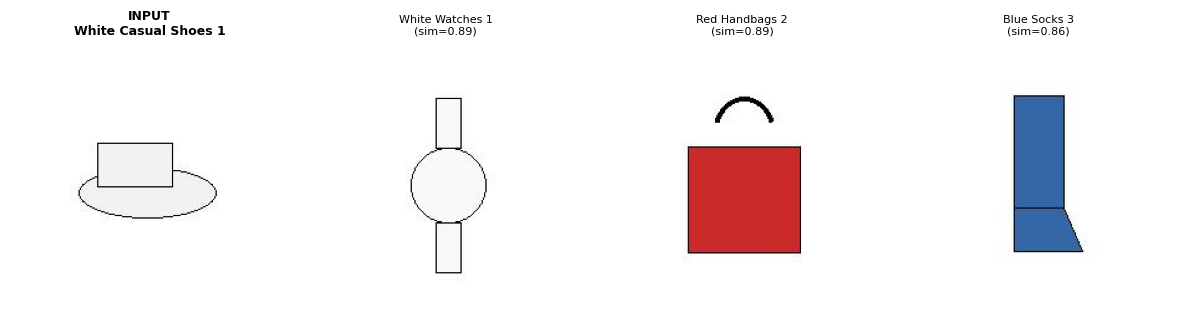

,id,productDisplayName,subCategory,similarity
23,10024,White Watches 1,Watches,0.893893
27,10028,Red Handbags 2,Bags,0.889274
21,10022,Blue Socks 3,Socks,0.855752


In [27]:
# --- Complementary category graph (curated; would normally be learned from co-purchase logs) ---
COMPLEMENTARY_MAP = {
    "Topwear":    ["Bottomwear", "Watches", "Bags", "Shoes"],
    "Bottomwear": ["Topwear", "Shoes", "Bags"],
    "Shoes":      ["Socks", "Watches", "Bags"],
    "Socks":      ["Shoes"],
    "Watches":    ["Topwear", "Bags"],
    "Bags":       ["Topwear", "Shoes"],
    "Bottle":     ["Shoes", "Bags"],
}

def recommend_complementary(product_id, top_k=3, per_category=1):
    row = df[df["id"] == product_id].iloc[0]
    src_subcat = row["subCategory"]
    src_vec = image_embeddings[df.index[df["id"] == product_id][0]].reshape(1, -1)

    target_cats = COMPLEMENTARY_MAP.get(src_subcat, [])
    candidates = df[df["subCategory"].isin(target_cats) & (df["id"] != product_id)]
    if candidates.empty:
        return pd.DataFrame(columns=df.columns)

    cand_idx = candidates.index.to_numpy()
    sims = cosine_similarity(src_vec, image_embeddings[cand_idx]).flatten()
    candidates = candidates.copy()
    candidates["similarity"] = sims

    # take the best match(es) per complementary category, then trim to top_k overall
    picks = (candidates.sort_values("similarity", ascending=False)
                        .groupby("subCategory", group_keys=False)
                        .head(per_category))
    return picks.sort_values("similarity", ascending=False).head(top_k)

def show_recommendations(product_id, top_k=3):
    row = df[df["id"] == product_id].iloc[0]
    recs = recommend_complementary(product_id, top_k=top_k)
    n = 1 + len(recs)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.2))
    if n == 1:
        axes = [axes]
    axes[0].imshow(Image.open(row["image_path"]))
    axes[0].set_title(f"INPUT\n{row['productDisplayName']}", fontsize=9, fontweight="bold")
    axes[0].axis("off")
    for ax, (_, r) in zip(axes[1:], recs.iterrows()):
        ax.imshow(Image.open(r["image_path"]))
        ax.set_title(f"{r['productDisplayName']}\n(sim={r['similarity']:.2f})", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return recs[["id", "productDisplayName", "subCategory", "similarity"]]

# Demo: pick a Footwear/Shoes item as the example input product
example_id = df[df["subCategory"] == "Shoes"]["id"].iloc[0] if (df["subCategory"] == "Shoes").any() else df["id"].iloc[0]
show_recommendations(example_id, top_k=3)

## Task 2 — Unique Product Catalog Creation (Deduplication)

**Approach.**
1. Compute CLIP image embeddings for every product (already done above).
2. Build a **pairwise cosine similarity matrix**.
3. Cluster products into groups of near-duplicates using **agglomerative clustering** with a *distance = 1 − cosine similarity* threshold — any two products more similar than the threshold end up in the same cluster (this naturally handles groups of 2, 3, or more near-duplicates, not just pairs).
4. From each cluster, keep **one representative** (the medoid — the item most similar, on average, to the rest of its cluster) to form the final deduplicated catalog.

The similarity threshold is a tunable knob: lower → merges more aggressively (fewer, broader duplicate groups), higher → stricter (only near-identical images merge).

In [28]:
# --- Deduplication via clustering on CLIP embeddings ---
SIMILARITY_THRESHOLD = 0.90  # tune per dataset; higher = stricter duplicate definition
distance_threshold = 1 - SIMILARITY_THRESHOLD

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=distance_threshold,
    metric="cosine",
    linkage="average",
)
cluster_labels = clustering.fit_predict(image_embeddings)
df["dup_cluster"] = cluster_labels

print(f"{df['id'].nunique()} products -> {df['dup_cluster'].nunique()} unique clusters "
      f"(threshold={SIMILARITY_THRESHOLD})")

def pick_representative(cluster_df):
    idxs = cluster_df.index.to_numpy()
    if len(idxs) == 1:
        return cluster_df.iloc[0]
    sims = cosine_similarity(image_embeddings[idxs])
    avg_sim = sims.mean(axis=1)
    best = idxs[np.argmax(avg_sim)]
    return df.loc[best]

reps = [pick_representative(g) for _, g in df.groupby("dup_cluster")]
unique_catalog = pd.DataFrame(reps).reset_index(drop=True)

print(f"Final unique catalog size: {len(unique_catalog)} (down from {len(df)})")
unique_catalog[["id", "productDisplayName", "subCategory", "baseColour"]].head(10)

33 products -> 11 unique clusters (threshold=0.9)
Final unique catalog size: 11 (down from 33)


,id,productDisplayName,subCategory,baseColour
0,10025,White Watches 2,Watches,White
1,10005,White Shirts 2,Topwear,White
2,10022,Blue Socks 3,Socks,Blue
3,10011,Blue Shorts 2,Bottomwear,Blue
4,10019,Pink Sports Shoes,Shoes,Pink
5,10033,Pink Water Bottle,Bottle,Pink
6,10001,Blue Tshirts 1,Topwear,Blue
7,10007,Pink Jeans 1,Bottomwear,Pink
8,10014,White Casual Shoes 1,Shoes,White
9,10027,Red Handbags 1,Bags,Red


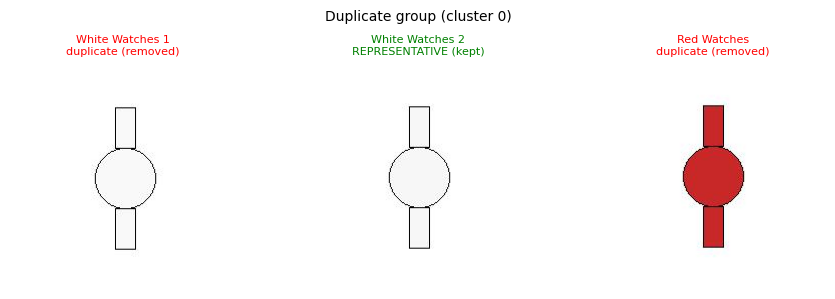

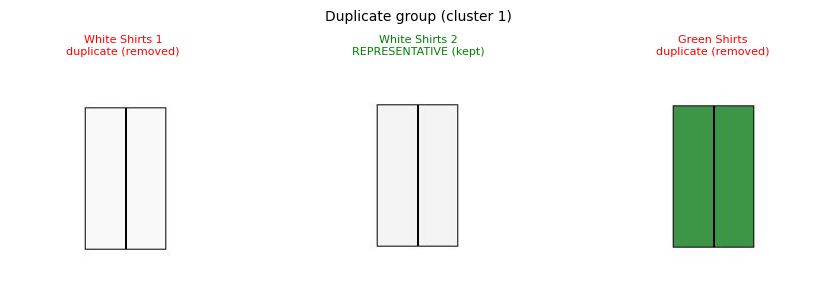

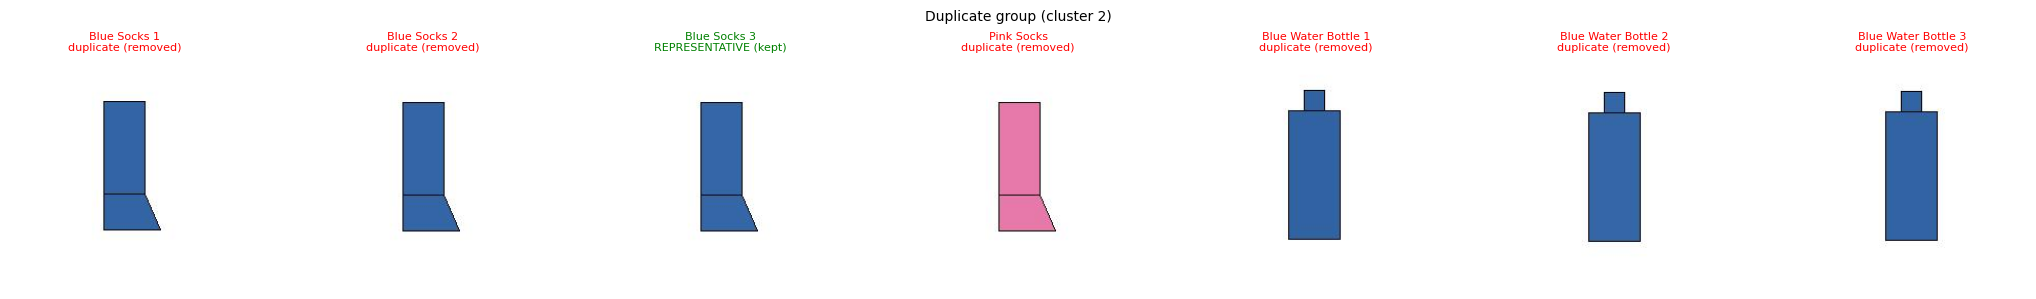

In [29]:
# --- Visualize a few duplicate groups vs. the chosen representative ---
dup_groups = df.groupby("dup_cluster").filter(lambda g: len(g) > 1).groupby("dup_cluster")
groups_to_show = list(dup_groups)[:3]

for cluster_id, group in groups_to_show:
    rep = pick_representative(group)
    fig, axes = plt.subplots(1, len(group), figsize=(3 * len(group), 3))
    if len(group) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, group.iterrows()):
        ax.imshow(Image.open(r["image_path"]))
        tag = "REPRESENTATIVE (kept)" if r["id"] == rep["id"] else "duplicate (removed)"
        ax.set_title(f"{r['productDisplayName']}\n{tag}", fontsize=8,
                      color="green" if r["id"] == rep["id"] else "red")
        ax.axis("off")
    fig.suptitle(f"Duplicate group (cluster {cluster_id})", fontsize=10)
    plt.tight_layout()
    plt.show()

if not groups_to_show:
    print("No duplicate groups found at this threshold in the current dataset.")

## Task 3 — Reverse Product Search (Text → Image)

**Approach.** CLIP embeds images and text into the **same shared vector space**, so a natural-language query like *"blue casual shirt"* can be compared directly against every product's image embedding using cosine similarity — no separate text index or keyword matching needed. This is the core trick the assignment hints at ("Explore CLIP Image and Text Embeddings").

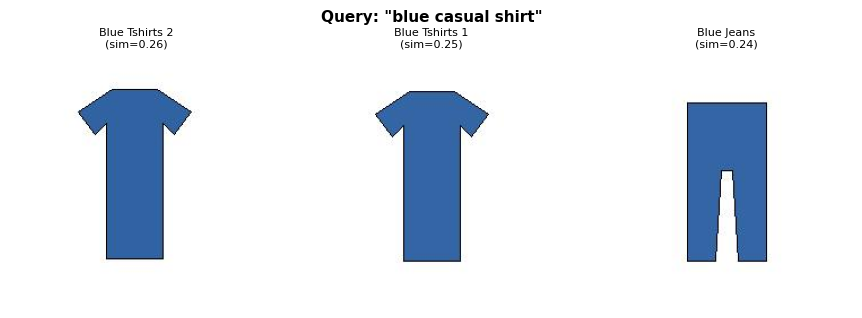

,id,productDisplayName,subCategory,baseColour,similarity
1,10002,Blue Tshirts 2,Topwear,Blue,0.257090
0,10001,Blue Tshirts 1,Topwear,Blue,0.252475
8,10009,Blue Jeans,Bottomwear,Blue,0.244540


In [30]:
# --- Text -> image search using CLIP's shared embedding space ---
def reverse_search(query, top_k=3):
    query_vec = embed_text([query])
    sims = cosine_similarity(query_vec, image_embeddings).flatten()
    top_idx = np.argsort(-sims)[:top_k]
    results = df.iloc[top_idx].copy()
    results["similarity"] = sims[top_idx]
    return results

def show_search_results(query, top_k=3):
    results = reverse_search(query, top_k=top_k)
    fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 3.2))
    if len(results) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, results.iterrows()):
        ax.imshow(Image.open(r["image_path"]))
        ax.set_title(f"{r['productDisplayName']}\n(sim={r['similarity']:.2f})", fontsize=8)
        ax.axis("off")
    fig.suptitle(f'Query: "{query}"', fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return results[["id", "productDisplayName", "subCategory", "baseColour", "similarity"]]

show_search_results("blue casual shirt", top_k=3)

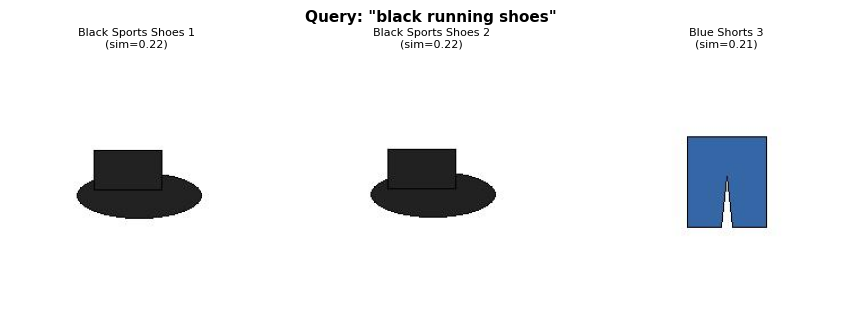

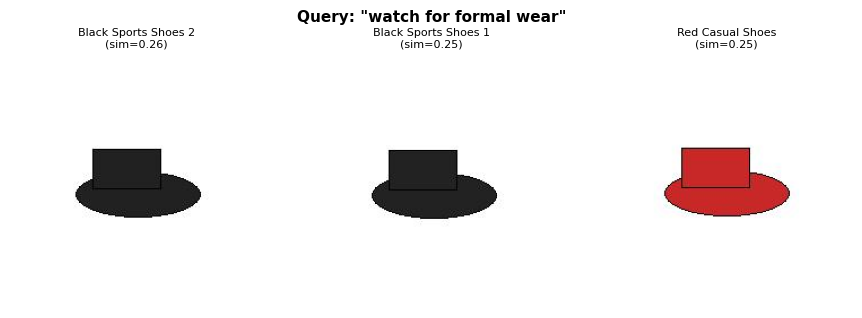

In [31]:
# Try a couple more queries
for q in ["black running shoes", "watch for formal wear"]:
    show_search_results(q, top_k=3)

## Summary

| Task | Technique | Key idea |
|---|---|---|
| 1. Recommendation Engine | Category co-purchase graph + CLIP embedding re-ranking | Combine domain rules (what's *usually* bought together) with content similarity (what *matches* the input product) |
| 2. Unique Catalog | Agglomerative clustering on CLIP image embeddings (cosine distance) | Group near-duplicate images, keep one medoid representative per cluster |
| 3. Reverse Search | CLIP's shared image/text embedding space | Encode the text query and images into the same space, then rank by cosine similarity |

**On Kaggle:** attach the `fashion-product-images-small` dataset as input, enable internet + GPU, and re-run — Cell 2 and Cell 3 will automatically pick up the real dataset and the real CLIP model with no code changes.

**Possible extensions:** learn the complementary-category graph from real co-purchase logs instead of curating it manually; use a finer similarity threshold sweep (with a labeled validation set) to tune Task 2; add a Streamlit/Gradio UI for Task 3's search box.